## Checking CUDA

In [1]:
# Check Pytorch installation
import torch, torchvision

print('torch version:', torch.__version__, torch.cuda.is_available())
print('torchvision version:', torchvision.__version__)

# Check MMPose installation
import mmpose

print('mmpose version:', mmpose.__version__)

# Check mmcv installation
from mmcv.ops import get_compiling_cuda_version, get_compiler_version

print('cuda version:', get_compiling_cuda_version())
print('compiler information:', get_compiler_version())

## MMPOSE

### Inferencer

In [17]:
from mmpose.apis import MMPoseInferencer
import matplotlib.pyplot as plt
%matplotlib inline

In [10]:
pose_inferencer_options = dict(
    det_model       = '../../mmdetection/configs/rtmdet/rtmdet_l_swin_b_p6_4xb16-100e_coco.py',
    det_weights     = '../../checkpoints/rtmdet_l_swin_b_p6_4xb16-100e_coco-a1486b6f.pth',
    pose2d          = '../../configs/animal_2d_keypoint/topdown_heatmap/ap10k/td-hm_hrnet-w48_8xb64-210e_ap10k-256x256.py',
    pose2d_weights  = '../../checkpoints/hrnet_w48_ap10k_256x256-d95ab412_20211029.pth',
    device          = 'cuda:0',
)
    
inferencer = MMPoseInferencer(**pose_inferencer_options)

Loads checkpoint by local backend from path: ../../checkpoints/hrnet_w48_ap10k_256x256-d95ab412_20211029.pth


/opt/conda/lib/python3.10/site-packages/mmpose/datasets/datasets/utils.py:102: UserWarning: The metainfo config file "configs/_base_/datasets/ap10k.py" does not exist. A matched config file "/opt/conda/lib/python3.10/site-packages/mmpose/.mim/configs/_base_/datasets/ap10k.py" will be used instead.
  warnings.warn(


Loads checkpoint by local backend from path: ../../checkpoints/rtmdet_l_swin_b_p6_4xb16-100e_coco-a1486b6f.pth


In [11]:
file = 'cow.png'
input_path = f'../../data/{file}'
output_path = '../../vis_results/out/'

result_generator = inferencer(
    input_path,
    radius=3,
    thickness=2,
    vis_out_dir=output_path,
    draw_heatmap=True,
    det_cat_ids=19
)

results = [res for res in result_generator]

03/12 14:57:04 - mmengine - INFO - the output image has been saved at ../../vis_results/out/cow.png


In [29]:
img.shape

(2852, 2163, 3)

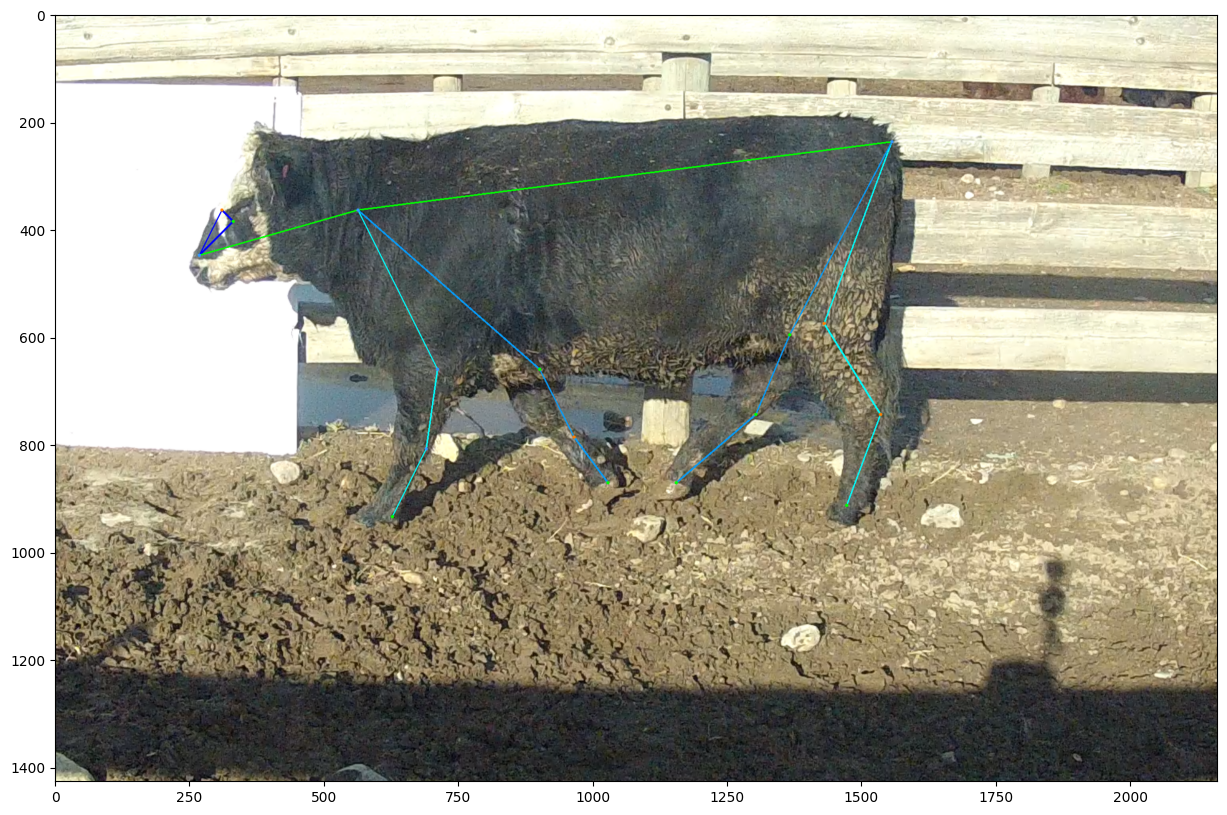

In [32]:
img = plt.imread(f'{output_path}/{file}')
pose = img[:img.shape[0]//2, :, :]
heatmap = img[img.shape[0]//2:, :, :]

fig = plt.figure(figsize=(15, 15))
ax_array = fig.subplots(2, 2, squeeze=False)
plt.figure(figsize=(15, 15))
plt.imshow()

### Python API

In [33]:
from mmcv.image import imread

from mmpose.apis import inference_bottomup, init_model
from mmpose.registry import VISUALIZERS
from mmpose.structures import merge_data_samples
from mmpose.evaluation.functional import nms
from mmpose.registry import VISUALIZERS
from mmpose.structures import merge_data_samples
from mmdet.apis import inference_detector, init_detector

det_cfg     = 'mmdetection/configs/rtmdet/rtmdet_l_swin_b_p6_4xb16-100e_coco.py'
det_ckpt    = 'checkpoints/rtmdet_l_swin_b_p6_4xb16-100e_coco-a1486b6f.pth'

pose_cfg    = 'configs/animal_2d_keypoint/topdown_heatmap/animalpose/td-hm_hrnet-w32_8xb64-210e_animalpose-256x256.py'
psoe_ckpt   = 'checkpoints/hrnet_w32_animalpose_256x256-1aa7f075_20210426.pth'

device = 'cuda'

cfg_options = {
    'model': {
        'test_cfg': {
            'output_heatmaps': True
        }
    },
    'visualizer': {
        'radius': 3,
        'line_width': 1
    }
}

In [23]:
detector = init_detector(
    det_cfg,
    det_ckpt,
    device=device
)

Loads checkpoint by local backend from path: checkpoints/rtmdet_l_swin_b_p6_4xb16-100e_coco-a1486b6f.pth


In [28]:
pose_estimator = init_model(
    pose_cfg,
    psoe_ckpt,
    device=device,
    cfg_options=cfg_options
)

Loads checkpoint by local backend from path: checkpoints/hrnet_w32_animalpose_256x256-1aa7f075_20210426.pth


In [31]:
visualizer = VISUALIZERS.build(pose_estimator.cfg.visualizer)
visualizer.set_dataset_meta(pose_estimator.dataset_meta)

/opt/conda/lib/python3.10/site-packages/mmengine/utils/manager.py:113: UserWarning: <class 'mmpose.visualization.local_visualizer.PoseLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(
